# 01. Panorama general de la demografía de negocios en Campeche

Nacimientos, muertes y sobrevivencia entre nov-2023 y nov-2024, para los 13 municipios y todos los giros.

In [1]:
import sqlite3
import importlib.util
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

DB = Path("data/denue.db")
if not DB.exists():
    DB = Path("../data/denue.db")
DB = DB.resolve()


def cargar_etl():
    ruta = Path("etl/02_matching_demografia.py")
    if not ruta.exists():
        ruta = Path("../etl/02_matching_demografia.py")
    ruta = ruta.resolve()
    spec = importlib.util.spec_from_file_location("etl_matching", ruta)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


## 1. Carga de datos

Lee de `data/denue.db`. Si no existe, regenera la base ejecutando `etl/02_matching_demografia.py` (Opción A).

In [2]:
if not DB.exists():
    mod = cargar_etl()
    mod.main()
    DB = mod.DB_PATH

con = sqlite3.connect(DB)
df23 = pd.read_sql("SELECT * FROM denue_2023", con)
df24 = pd.read_sql("SELECT * FROM denue_2024", con)
sobre = pd.read_sql("SELECT * FROM sobrevivientes", con)
nac = pd.read_sql("SELECT * FROM nacimientos", con)
mue = pd.read_sql("SELECT * FROM muertes", con)
con.close()

print(f"Unidades 2023: {len(df23):,}")
print(f"Unidades 2024: {len(df24):,}")
print(f"Sobrevivientes: {len(sobre):,}  |  Nacimientos: {len(nac):,}  |  Muertes: {len(mue):,}")


Unidades 2023: 41,783
Unidades 2024: 46,923
Sobrevivientes: 28,984  |  Nacimientos: 17,939  |  Muertes: 12,799


## 2. Verificación de consistencia

In [3]:
s, n, m = len(sobre), len(nac), len(mue)
assert s + m == len(df23), "S + M no cuadra con 2023"
assert s + n == len(df24), "S + N no cuadra con 2024"
print(f"S + M = {s + m:,}  (2023: {len(df23):,})")
print(f"S + N = {s + n:,}  (2024: {len(df24):,})")

S + M = 41,783  (2023: 41,783)
S + N = 46,923  (2024: 46,923)


## 3. Tasas por municipio

Métricas (en %):

> **Nota:** U23 = unidades económicas (negocios) en 2023; U24 = unidades económicas en 2024.

- **Tasa de supervivencia** = `S / U23`
- **Tasa de natalidad** = `N / U24`
- **Tasa de mortalidad** = `M / U23`
- **Crecimiento neto** = `(U24 - U23) / U23`

In [4]:
def resumen_por_clave(col):
    u23 = df23.groupby(col).size()
    u24 = df24.groupby(col).size()
    s = sobre.groupby(col).size()
    n = nac.groupby(col).size()
    m = mue.groupby(col).size()
    r = pd.DataFrame({
        "Unidades_2023": u23, "Unidades_2024": u24, "Sobrevivientes": s,
        "Nacimientos": n, "Muertes": m,
    }).fillna(0).astype(int)
    r["tasa_supervivencia"] = (r["Sobrevivientes"] / r["Unidades_2023"] * 100).round(1)
    r["tasa_natalidad"] = (r["Nacimientos"] / r["Unidades_2024"] * 100).round(1)
    r["tasa_mortalidad"] = (r["Muertes"] / r["Unidades_2023"] * 100).round(1)
    r["crecimiento_neto"] = ((r["Unidades_2024"] - r["Unidades_2023"]) / r["Unidades_2023"] * 100).round(1)
    return r


In [5]:
nombres = df23.drop_duplicates("cve_mun").set_index("cve_mun")["municipio"]
tabla_mun = resumen_por_clave("cve_mun")
tabla_mun.insert(0, "municipio", nombres.reindex(tabla_mun.index).values)
tabla_mun.sort_values("crecimiento_neto", ascending=False)

,municipio,Unidades_2023,Unidades_2024,Sobrevivientes,Nacimientos,Muertes,tasa_supervivencia,tasa_natalidad,tasa_mortalidad,crecimiento_neto
cve_mun,,,,,,,,,,
010,Calakmul,634,814,444,370,188,70.0,45.5,29.7,28.4
013,Dzitbalché,994,1275,777,498,238,78.2,39.1,23.9,28.3
006,Hopelchén,1049,1322,795,527,256,75.8,39.9,24.4,26.0
003,Carmen,11875,14388,8228,6160,3647,69.3,42.8,30.7,21.2
005,Hecelchakán,1123,1308,861,447,278,76.7,34.2,24.8,16.5
009,Escárcega,2590,2962,1788,1174,808,69.0,39.6,31.2,14.4
008,Tenabo,573,636,430,206,151,75.0,32.4,26.4,11.0
004,Champotón,3275,3558,2243,1315,1038,68.5,37.0,31.7,8.6
002,Campeche,14638,15518,9814,5704,4761,67.0,36.8,32.5,6.0


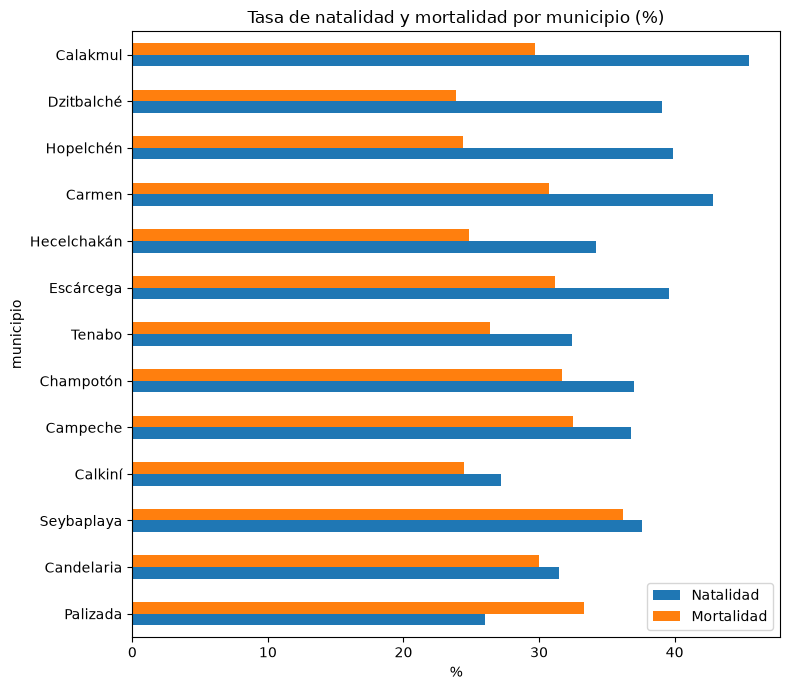

In [6]:
orden = tabla_mun.sort_values("crecimiento_neto")["municipio"]
tabla_mun.set_index("municipio").loc[orden][["tasa_natalidad", "tasa_mortalidad"]].plot.barh(figsize=(8, 7))
plt.title("Tasa de natalidad y mortalidad por municipio (%)")
plt.xlabel("%")
plt.legend(["Natalidad", "Mortalidad"])
plt.tight_layout()
plt.show()

## 4. Distribución por sector de servicios

Niveles: núcleo (7211, 7225, 5615), ampliado (7224, 7132, 7121), excluido (4871) y resto.

In [7]:
por_sector = pd.DataFrame({
    "Sobrevivientes": sobre["sector_servicios"].value_counts(),
    "Nacimientos": nac["sector_servicios"].value_counts(),
    "Muertes": mue["sector_servicios"].value_counts(),
}).fillna(0).astype(int)
por_sector.reindex(["nucleo", "ampliado", "excluido", "resto"])

,Sobrevivientes,Nacimientos,Muertes
sector_servicios,,,
nucleo,3608,2844,1866
ampliado,235,121,122
excluido,13,1,2
resto,25128,14973,10809


## 5. Distribución por tamaño (personal ocupado)

In [8]:
orden_tam = [
    "0 a 5 personas", "6 a 10 personas", "11 a 30 personas",
    "31 a 50 personas", "51 a 100 personas", "101 a 250 personas",
    "251 y más personas",
]

def distribucion_tamano(df):
    cat = pd.Categorical(df["per_ocu"], categories=orden_tam, ordered=True)
    return pd.Series(cat).value_counts().sort_index()

tam = pd.DataFrame({"2023": distribucion_tamano(df23), "2024": distribucion_tamano(df24)})
tam

,2023,2024
0 a 5 personas,35255,40252
6 a 10 personas,3118,3605
11 a 30 personas,2352,2086
31 a 50 personas,467,397
51 a 100 personas,301,323
101 a 250 personas,196,183
251 y más personas,94,77


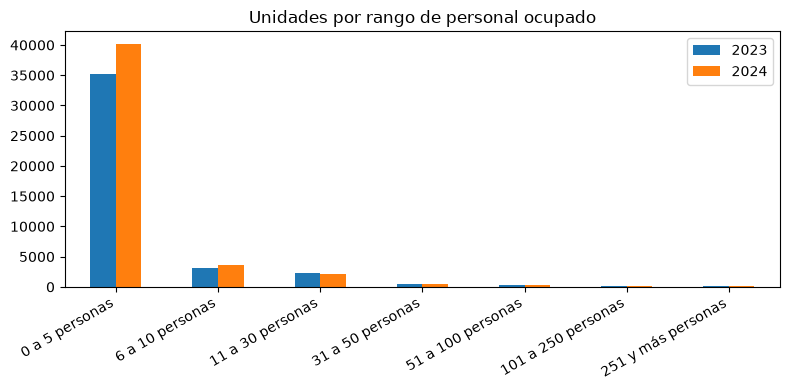

In [9]:
tam.plot.bar(figsize=(8, 4))
plt.title("Unidades por rango de personal ocupado")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Hallazgos preliminares

**1. El tejido empresarial crecio de forma generalizada, pero desigual.**
Entre nov-2023 y nov-2024 la base de unidades paso de 41,783 a 46,923 (+12.3%), con 17,939 nacimientos frente a 12,799 muertes. En 12 de los 13 municipios la natalidad supera a la mortalidad, de modo que el crecimiento no se limita a unos pocos polos: es un fenomeno extendido.

**2. El mayor crecimiento neto se concentra en municipios pequenos.**
Calakmul (+29.1%), Dzitbalche (+28.3%) y Hopelchen (+25.7%) encabezan el crecimiento neto. Son municipios con una base empresarial reducida, donde cada nueva unidad tiene un impacto porcentual grande; su dinamismo refleja una linea de partida baja mas que una expansion absoluta masiva.

**3. Palizada es el unico municipio en contraccion.**
Con una tasa de mortalidad superior a la de natalidad, su tejido empresarial se redujo entre ambas ediciones, lo que lo distingue del resto del estado y lo convierte en un caso atipico que merece atencion.

**4. La economia local es abrumadoramente microempresarial.**
El 85.7% de las unidades tiene entre 0 y 5 personas ocupadas. Esta estructura de escala minima es coherente con la paradoja del PIB campechano: una produccion petrolera muy alta convive con un tejido productivo de base fragil y de baja escala.

**5. El nucleo de servicios es minoritario frente al resto de la economia.**
Con 3,608 sobrevivientes (frente a 235 del nivel ampliado, 13 del excluido y 25,128 del resto), los giros de alojamiento, alimentos y agencias representan una fraccion acotada del total. Su peso relativo es pequeno, por lo que su comportamiento dificilmente mueve los agregados estatales, pero si importa para el analisis del Tren Maya (notebook 02).

**6. Alta rotación: el crecimiento no equivale a desarrollo.**
El crecimiento de +12.3% esconde una alta rotación empresarial: solo el 69.4% de los negocios de 2023 sobrevivió a 2024 (28,984 de 41,783) y el 30.6% murió (12,799). El crecimiento neto (+5,140 unidades) se debe a 17,939 nacimientos, no al fortalecimiento de los negocios existentes. La economía local se reemplaza más de lo que se desarrolla.

> Nota de interpretacion: la edicion nov-2024 esta ligada a los Censos Economicos 2024 (actualizacion exhaustiva), por lo que parte del crecimiento observado puede deberse a una mejor cobertura censal y no solo a nueva actividad economica.
